## Mathematical Transformations of Features

- Log Transformation
- Reciprocal Transformation
- Power Transformation
- Box-Cox Transformation
- Yeo-Johnson Transformation

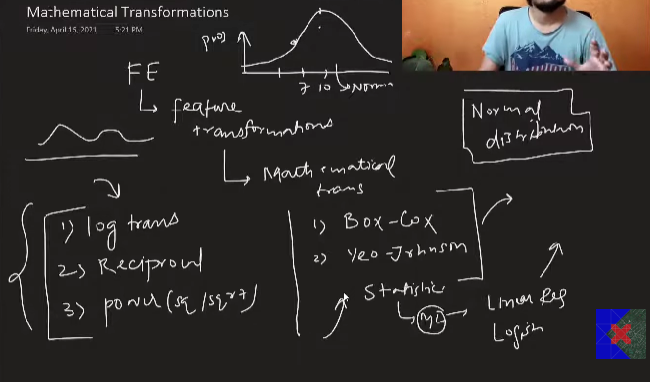

- The main motive of this transformation is to make the distribution(probability density) of the data as normal distribution.

### Why to do normal distribution?
- Normal distribution k ird gird calsulation easy hota hai.
- Algorithms like linear regression, logistic regression, etc. mei hum assume krke chalte hai ki data normal distribution follow krta hai. Agar data normal distribution follow nahi krta hai toh use hum normal distribution mei convert krna padta hai taki humare algorithms sahi se kaam kare.

- However algo like decision tree, random forest, etc. mei data normal distribution follow krna zaruri nahi hota hai.

### There are 3 types of mathematical transformers in sklearn:
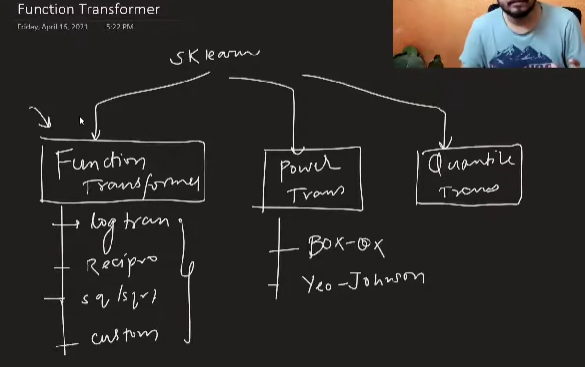

# How to find if the data is normally distributed or not?

1. Using sns.distplot() or sns.histplot() to visualize the distribution of the data.
2. using pd.DataFrame.skew() to find the skewness of the data. If the skewness is between -0.5 to 0.5 then the data is normally distributed. If the skewness is less than -0.5 then the data is left skewed and if the skewness is greater than 0.5 then the data is right skewed.

3. <span style="color:orange">But the most reliable method is using the Q-Q plot (Quantile-Quantile plot)</span>

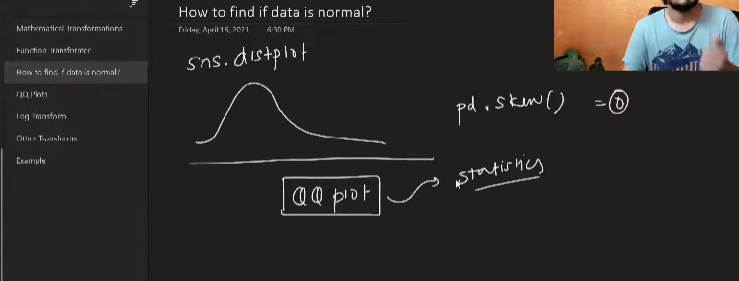

## <span style="color:orange">Q-Q plot (Quantile-Quantile plot)</span>
- If the data is normally distributed then the points in the Q-Q plot will lie on the straight line. If the points are above the straight line then the data is right skewed and if the points are below the straight line then the data is left skewed.

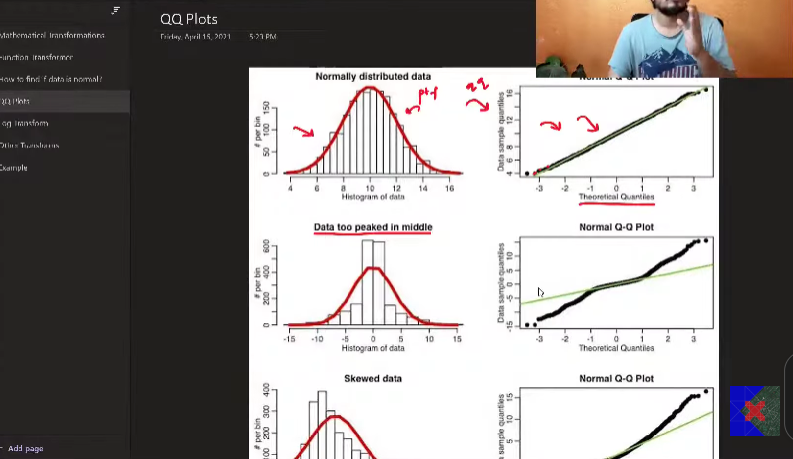

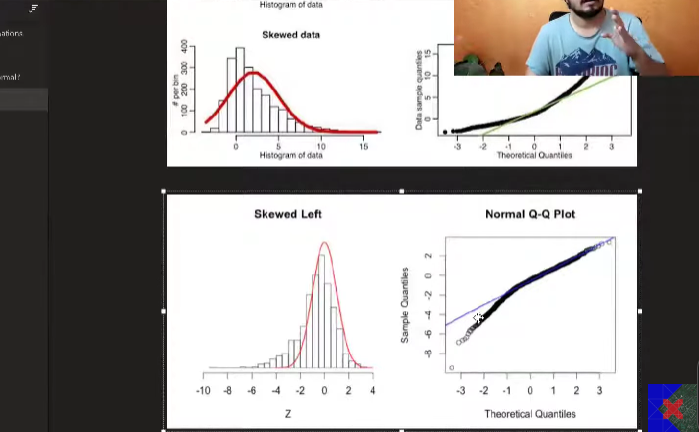](attachment:image-2.png)

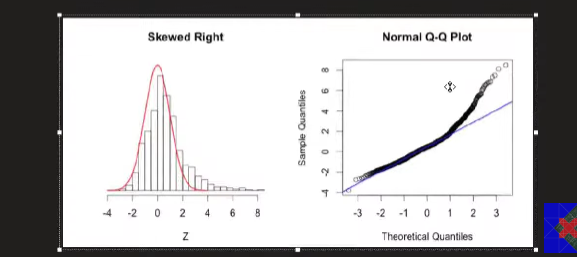

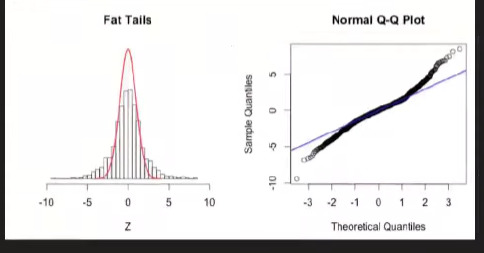

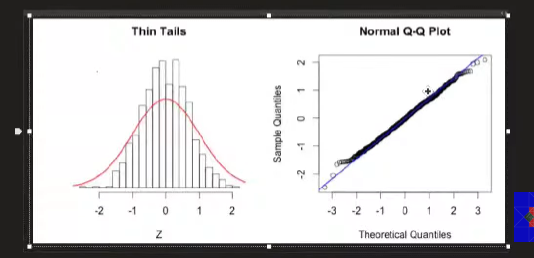

**<span style="color:orange">So, jitna jada aap line k paa, utna jada normally distributed hai data, and jitna jada line se deviation hai, utna jada non-normal data hai.</span>**

# <span style="color:orange">Log Transformation</span>
- Log transformation is used to make the data normally distributed.
- It is used when the data is right skewed.
- The log transformation is applied as: `np.log(data)` or `np.log1p(data)` where `log1p` is used to handle zero values.

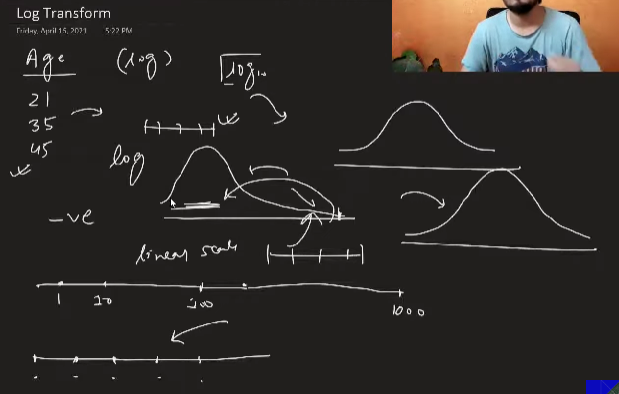

- Suppose a data ranges from 1, 10, 100, 1000, 10000. After log transformation, the data will be transformed to 0, 1, 2, 3, 4. So, the range of the data is reduced and the data is more normally distributed after log transformation.
- It kind of make the data more linear and less skewed.

# <span style="color:orange">Other Transformations</span>

- Reciprocal Transformation
- Square Transformation (Used for left skewed data)
- Square Root Transformation

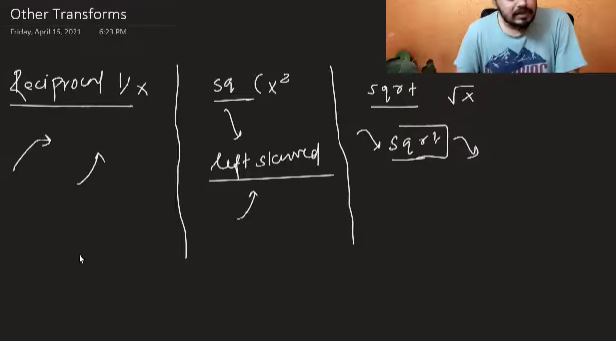

### <span style="color:orange">IMP NOTE</span>

- In general if data is right skewed then we can apply log transformation.
- If data is left skewed then we can apply square transformation.
- But like try all the transformation mentioned and see which transformation gives the best result. (Just one line of change in code and see the result, which transformation is best for your data.)

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats # For Q-Q plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [ ]:
# write code to handle missing values in Age column using SimpleImputer (Originally in the video, they directly replacced by the mean value but I thought it would be better to use SimpleImputer to handle missing values in a more systematic way)
# Define the transformer
imputer = SimpleImputer()
# Define the column transformer
ct = ColumnTransformer(transformers=[('imputer', imputer, ['Age'])], remainder='passthrough')
# Fit and transform the data
df= ct.fit_transform(df)


In [7]:
df

array([[22.        ,  0.        ,  7.25      ],
       [38.        ,  1.        , 71.2833    ],
       [26.        ,  1.        ,  7.925     ],
       ...,
       [29.69911765,  0.        , 23.45      ],
       [26.        ,  1.        , 30.        ],
       [32.        ,  0.        ,  7.75      ]], shape=(891, 3))

In [8]:
# Convert the transformed data back to a DataFrame
df = pd.DataFrame(df, columns=['Age', 'Survived', 'Fare'])

In [9]:
df.isnull().sum()

Age         0
Survived    0
Fare        0
dtype: int64

In [10]:
df.head()

,Age,Survived,Fare
0,22.0,0.0,7.2500
1,38.0,1.0,71.2833
2,26.0,1.0,7.9250
3,35.0,1.0,53.1000
4,35.0,0.0,8.0500


In [12]:
X = df.iloc[:, [0, 2]] # Age and Survived are 0th and 2nd columns respectively
y = df.iloc[:,1]

In [13]:
X.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_33408\2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


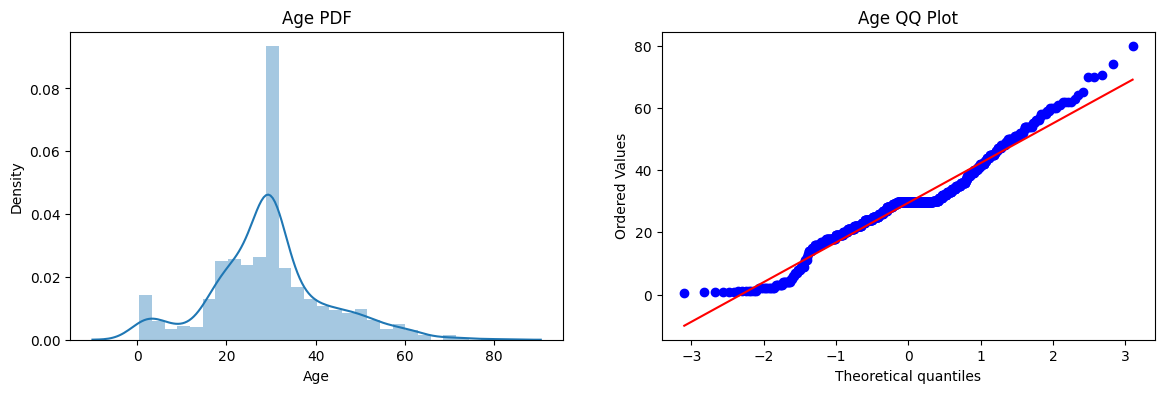

In [15]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_33408\2981780686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


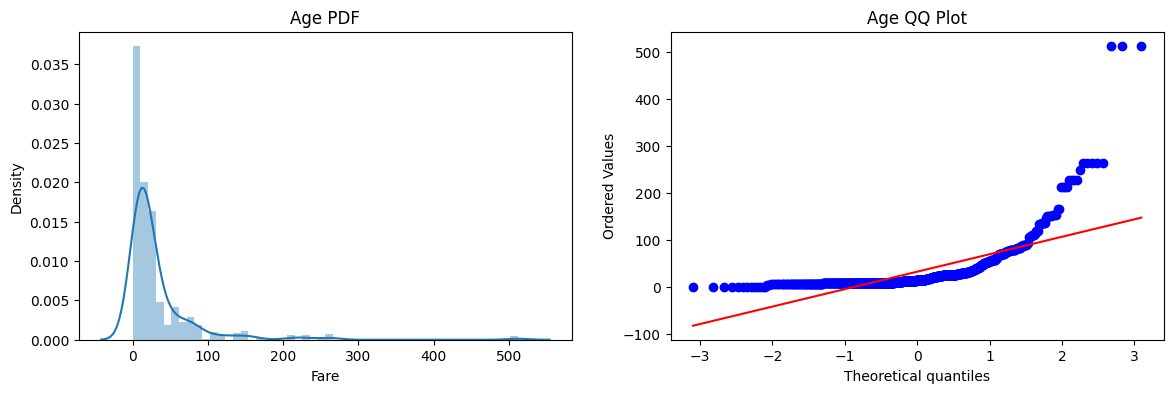

In [16]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [17]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [18]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6927374301675978


## Let's apply FunctionTransformer and see if the acurracy of the model improves or not.

In [19]:
trf = FunctionTransformer(func=np.log1p)
# log1p is used to handle zero values in Fare column, as log(0) is undefined
# it adds 1 to the input before applying the logarithm, so log1p(0) will return 0 instead of -inf

In [20]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6815642458100558


- See there is improvement in the accuracy in Logistic Regression model after applying log transformation
- However, to verify the results, we do cross validation and see the results. (Because sometimes, the improvement in accuracy may be due to random chance and not due to the transformation applied)

In [ ]:
# cross validation to verify the results
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6655930087390761


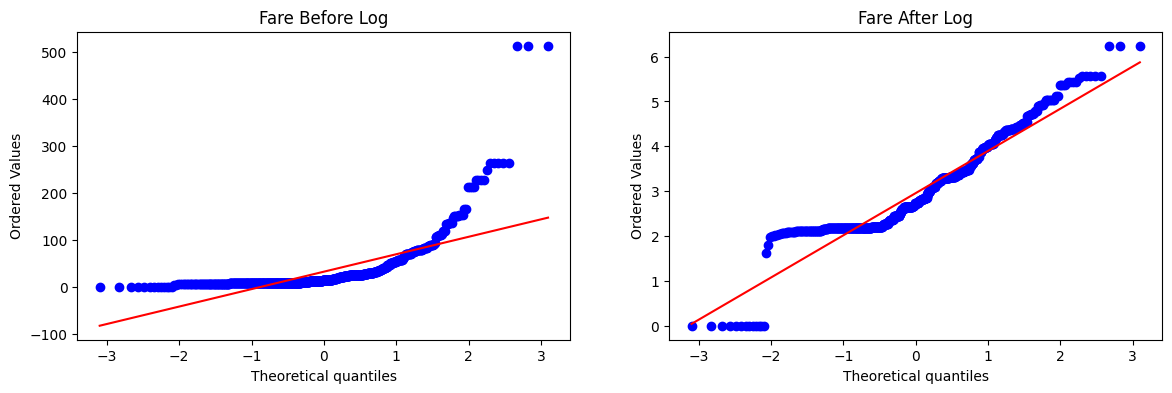

In [23]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

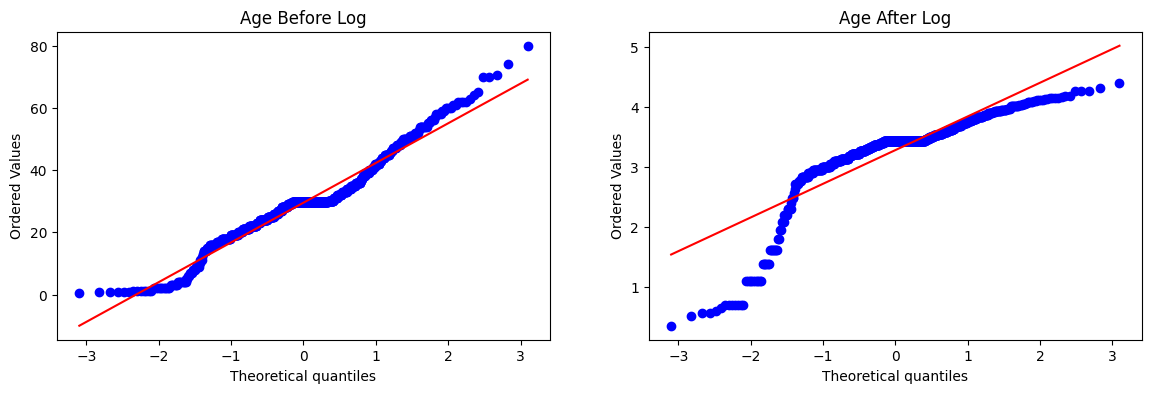

In [24]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

- For Age earlier it was good but later it became bad, so we can say that log transformation is not good for Age column but it is good for Fare column. So, we can apply log transformation only on Fare column and not on Age column.

In [ ]:
# appling log transformation only on Fare column and not on Age column
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [26]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.664804469273743


In [27]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6621972534332085


In [28]:
# Function to apply any transformation and see the results
def apply_transform(transform):
    X = df.iloc[:,[0,2]]
    y = df.iloc[:,1]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6589013732833957


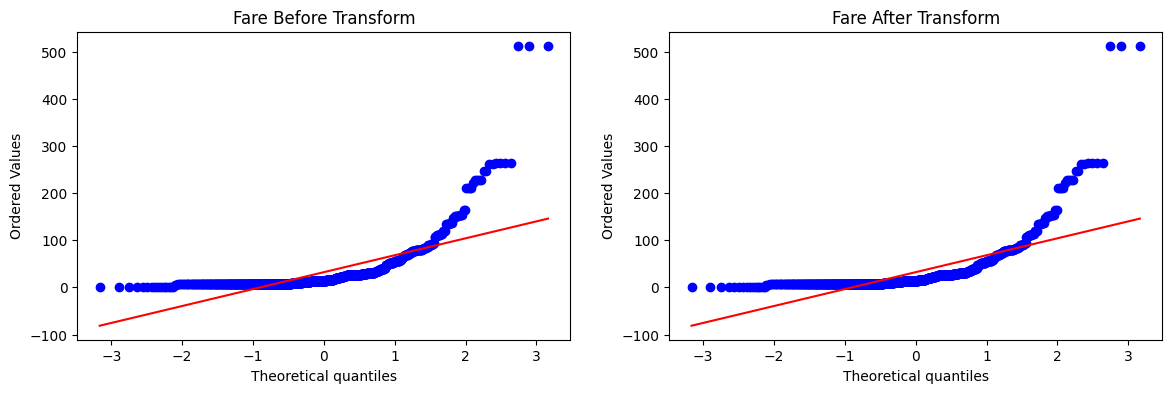

In [29]:
apply_transform(lambda x: x) # no transformation

Accuracy 0.6431335830212235


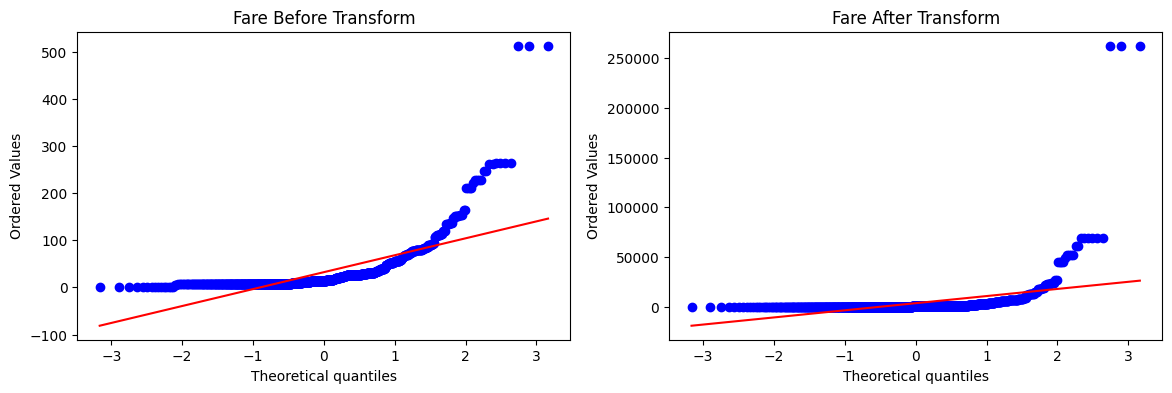

In [31]:
apply_transform(lambda x: x**2) # square transformation

Accuracy 0.61729088639201


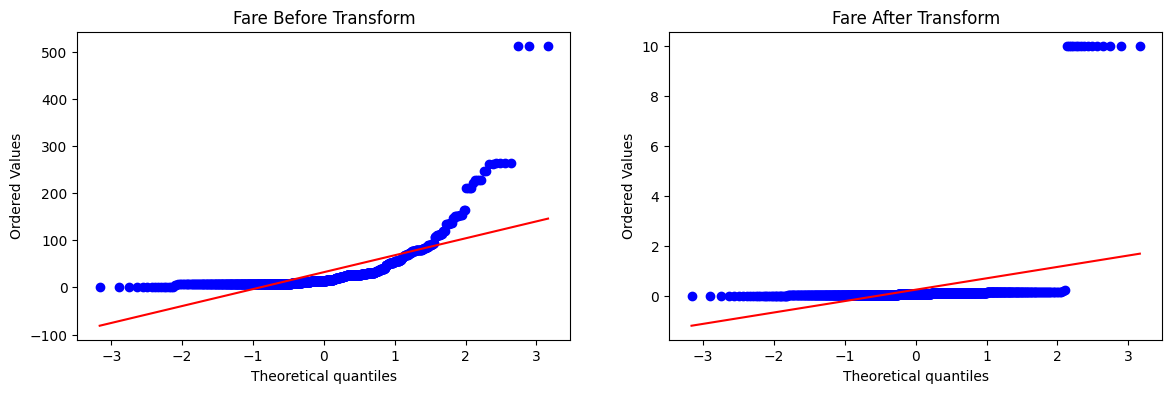

In [35]:
apply_transform(lambda x: 1/(x+0.1)) # reciprocal transformation

Accuracy 0.6712609238451936


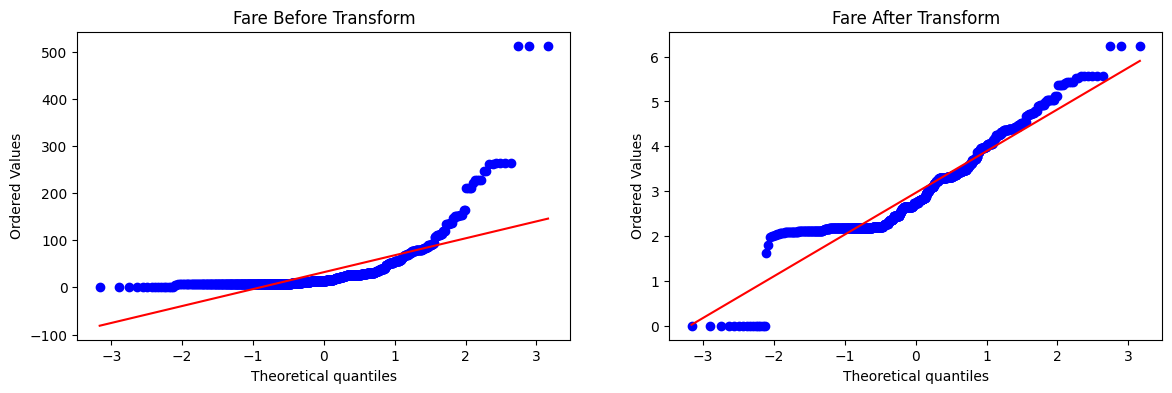

In [36]:
apply_transform(np.log1p)

Accuracy 0.6195131086142323


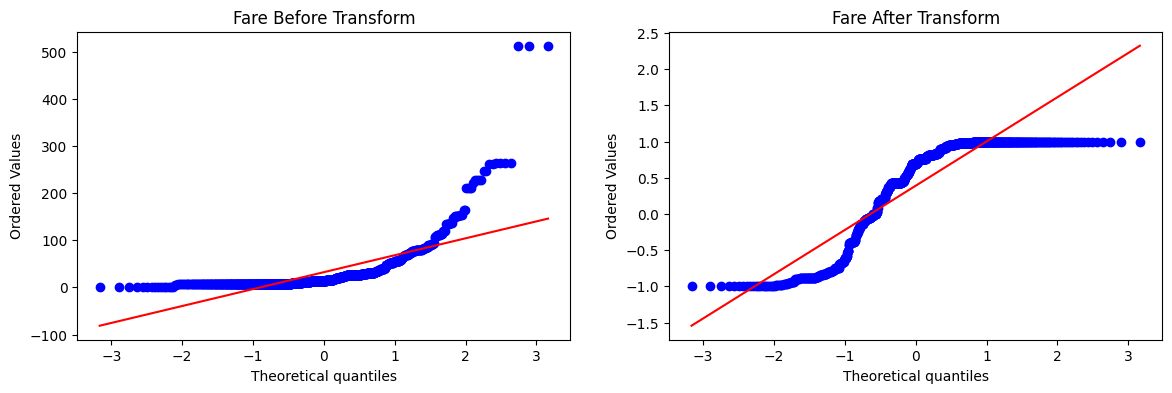

In [30]:
apply_transform(np.sin)